# AirBnB Effect Study — EDA

**Città analizzate:** Roma · Milano · Firenze (Italia) &nbsp;|&nbsp; New York (USA)

---

## Step 1: Caricamento e preparazione dati

### Fonti dati

| Fonte | Descrizione | Percorso |
|-------|------------|----------|
| **Airbnb — Italia 2024** | 4 snapshot trimestrali (mar · giu · set · dic) | `data/airbnb/italy_2024/airbnb.csv` |
| **Airbnb — NY 2023-2024** | 2 snapshot Kaggle zip | `data/airbnb/new_york_2023_2024/` |
| **Airbnb — Inside Airbnb 2025** | Snapshot mensili `.csv.gz` | `data/airbnb/insideairbnb_2025/<city>/` |
| **OMI — Quotazioni immobiliari** | Valori di mercato + Zone OMI (semestre) | `data/omi/<city>/` |
| **Zillow ZORI** | Indice affitti mensile per ZIP code NYC | `data/airbnb/new_york_2023_2024/new_york_data.csv` |

### Snapshot Airbnb per città

| Città | Fonte 2024 | Fonte 2025 | Snapshot totali |
|-------|-----------|-----------|----------------|
| Roma | airbnb.csv (4 trim.) | Inside Airbnb (3 snap.) | 7 |
| Milano | airbnb.csv (4 trim.) | Inside Airbnb (2 snap.) | 6 |
| Firenze | airbnb.csv (4 trim.) | Inside Airbnb (3 snap.) | 7 |
| New York | Kaggle zip (2 snap.) | Inside Airbnb (11 snap.) | 13 |

### Dati OMI per città (solo Italia)

| Città | Semestri disponibili |
|-------|---------------------|
| Roma | 2023/1 · 2023/2 · 2024/1 · 2024/2 · 2025/1 |
| Milano | 2023/1 · 2023/2 · 2024/1 · 2024/2 · 2025/1 |
| Firenze | 2023/1 · 2023/2 · 2024/1 · 2024/2 · 2025/1 |

**Output Step 1:** `data/processed/<city>.csv` · `data/processed/master_airbnb.csv` · `data/processed/omi_<city>.csv`  
**Output Step 2:** `data/processed/panel_italy.csv` · `data/processed/panel_ny.csv`  
**Output Step 3:** `plots/*.png`


In [1]:
import pandas as pd
import zipfile
import glob
import os

# Cartella di output
OUTPUT_DIR = 'data/processed'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Città italiane incluse (Roma e Milano hanno anche dati 2025;
# Firenze è la 3ª città IT per volume con ~41k annunci)
CITIES_IT = ['Roma', 'Milano', 'Firenze']

# Schema colonne comune per tutti i CSV finali
FINAL_COLS = [
    'id', 'city', 'neighbourhood', 'room_type', 'price', 'date',
    'number_of_reviews', 'number_of_reviews_ltm',
    'reviews_per_month', 'availability_365', 'minimum_nights', 'source'
]

print("Output dir:", os.path.abspath(OUTPUT_DIR))
print("Colonne finali:", FINAL_COLS)


Output dir: C:\Users\user\Progetti\airbnb\data\processed
Colonne finali: ['id', 'city', 'neighbourhood', 'room_type', 'price', 'date', 'number_of_reviews', 'number_of_reviews_ltm', 'reviews_per_month', 'availability_365', 'minimum_nights', 'source']


## Funzioni di caricamento

Quattro funzioni, una per fonte:
- **`load_italy_2024`** — legge `airbnb.csv` (formato custom, 4 snapshot trimestrali 2024)
- **`load_ny_zip`** — legge gli snapshot NY da file zip Kaggle (data assegnata manualmente)
- **`load_insideairbnb_2025`** — legge i file `.csv.gz` Inside Airbnb 2025 (formato ricco con `last_scraped`)
- **`load_omi`** — legge i file VALORI + ZONE dell'Osservatorio del Mercato Immobiliare (OMI)

In [2]:
def load_italy_2024(csv_path, cities):
    """
    Carica data/airbnb/italy_2024/airbnb.csv e filtra per le città richieste.
    Periodo: 4 snapshot trimestrali (2024-03, 2024-06, 2024-09, 2024-12).
    Nota: availability_365 e minimum_nights non presenti in questa fonte → NaN.
    """
    df = pd.read_csv(csv_path)
    df = df[df['City'].isin(cities)].copy()
    df = df.rename(columns={
        'Listings id':       'id',
        'City':              'city',
        'Neighbourhood':     'neighbourhood',
        'Property type':     'room_type',
        'Price':             'price',
        'Date of scraping':  'date',
        'Total reviews':     'number_of_reviews',
        'Last year reviews': 'number_of_reviews_ltm',
        'Reviews per month': 'reviews_per_month',
    })
    df['date'] = pd.to_datetime(df['date'])
    df['source'] = 'insideairbnb_2024'
    df['availability_365'] = pd.NA
    df['minimum_nights'] = pd.NA
    return df.reindex(columns=FINAL_COLS)


def load_ny_zip(zip_path, approx_date):
    """
    Carica uno snapshot New York da file zip (2023 o 2024).
    La data di scraping è assegnata manualmente — il file non contiene last_scraped,
    viene stimata in base al range di last_review presente nel dataset.
    """
    with zipfile.ZipFile(zip_path) as z:
        with z.open(z.namelist()[0]) as f:
            df = pd.read_csv(f, low_memory=False)
    df['city'] = 'New York'
    df['date'] = pd.to_datetime(approx_date)
    df['source'] = 'kaggle_zip'
    if 'number_of_reviews_ltm' not in df.columns:
        df['number_of_reviews_ltm'] = pd.NA
    return df.reindex(columns=FINAL_COLS)


def load_insideairbnb_2025(file_list, city_name):
    """
    Carica snapshot mensili da file .csv.gz Inside Airbnb 2025.
    Formato ricco: last_scraped, availability_365, minimum_nights, reviews, ecc.
    """
    dfs = []
    for f in file_list:
        df = pd.read_csv(f, usecols=[
            'id', 'neighbourhood_cleansed', 'room_type', 'price',
            'last_scraped', 'number_of_reviews', 'number_of_reviews_ltm',
            'reviews_per_month', 'availability_365', 'minimum_nights'
        ], low_memory=False)
        if df['price'].dtype == object:
            df['price'] = df['price'].str.replace(r'[\$,]', '', regex=True).astype(float)
        df = df.rename(columns={
            'neighbourhood_cleansed': 'neighbourhood',
            'last_scraped':           'date',
        })
        df['date'] = pd.to_datetime(df['date'])
        df['city'] = city_name
        df['source'] = 'insideairbnb_2025'
        dfs.append(df.reindex(columns=FINAL_COLS))
    return pd.concat(dfs, ignore_index=True)


def load_omi(city_name, omi_dir='data/omi'):
    """
    Carica e unisce i file VALORI e ZONE dell'OMI per una città.
    - VALORI: quotazioni di mercato (€/m², compravendita e locazione) per zona/tipologia
    - ZONE: descrizione delle zone OMI (microzone, fasce, denominazioni)
    Restituisce (df_valori, df_zone) con colonna 'semestre' aggiunta (es. '2024_1').
    """
    import re
    city_upper = city_name.upper()
    city_dir = os.path.join(omi_dir, city_name)

    dfs_valori, dfs_zone = [], []
    for f in sorted(glob.glob(os.path.join(city_dir, f'{city_upper}_VALORI_*.csv'))):
        match = re.search(r'(\d{4}_\d)', os.path.basename(f))
        sem = match.group(1) if match else 'unknown'
        df = pd.read_csv(f, sep=';', skiprows=1)
        df = df.drop(columns=[c for c in df.columns if c.startswith('Unnamed')], errors='ignore')
        df['semestre'] = sem
        df['city'] = city_name
        dfs_valori.append(df)

    for f in sorted(glob.glob(os.path.join(city_dir, f'{city_upper}_ZONE_*.csv'))):
        match = re.search(r'(\d{4}_\d)', os.path.basename(f))
        sem = match.group(1) if match else 'unknown'
        df = pd.read_csv(f, sep=';', skiprows=1)
        df = df.drop(columns=[c for c in df.columns if c.startswith('Unnamed')], errors='ignore')
        df['semestre'] = sem
        df['city'] = city_name
        dfs_zone.append(df)

    df_valori = pd.concat(dfs_valori, ignore_index=True) if dfs_valori else pd.DataFrame()
    df_zone = pd.concat(dfs_zone, ignore_index=True) if dfs_zone else pd.DataFrame()
    return df_valori, df_zone


print("Funzioni caricate.")

Funzioni caricate.


## 1. Dati italiani 2024 — `airbnb.csv`

Fonte: `data/airbnb/italy_2024/airbnb.csv`  
Periodo: 4 snapshot trimestrali (mar · giu · set · dic 2024)  
⚠️ `availability_365` e `minimum_nights` **non disponibili** in questa fonte → `NaN`

In [3]:
print("Caricamento airbnb.csv (Italia 2024)...")
df_italy = load_italy_2024('data/airbnb/italy_2024/airbnb.csv', CITIES_IT)

df_roma_24    = df_italy[df_italy['city'] == 'Roma'].copy()
df_milano_24  = df_italy[df_italy['city'] == 'Milano'].copy()
df_firenze_24 = df_italy[df_italy['city'] == 'Firenze'].copy()

for label, df in [('Roma', df_roma_24), ('Milano', df_milano_24), ('Firenze', df_firenze_24)]:
    dates = sorted(df['date'].dt.strftime('%Y-%m').unique())
    print(f"  {label:<10}: {len(df):>6} righe | {len(dates)} snapshot → {dates}")

Caricamento airbnb.csv (Italia 2024)...


  Roma      : 104981 righe | 4 snapshot → ['2024-03', '2024-06', '2024-09', '2024-12']


  Milano    :  75889 righe | 4 snapshot → ['2024-03', '2024-06', '2024-09', '2024-12']
  Firenze   :  41243 righe | 4 snapshot → ['2024-03', '2024-06', '2024-09', '2024-12']


## 2. Dati 2025 — Inside Airbnb (`.csv.gz`)

Fonte: `data/airbnb/insideairbnb_2025/<city>/*.csv.gz`  
Formato ricco con `last_scraped`, `availability_365`, `minimum_nights`, ecc.

| Città | Snapshot disponibili |
|-------|---------------------|
| Roma | 3 snapshot |
| Milano | 2 snapshot |
| Firenze | 3 snapshot |
| New York | 11 snapshot |

In [4]:
print("Caricamento dati 2025 (Inside Airbnb)...")

df_roma_25    = load_insideairbnb_2025(sorted(glob.glob('data/airbnb/insideairbnb_2025/Roma/*.csv.gz')),     'Roma')
df_milano_25  = load_insideairbnb_2025(sorted(glob.glob('data/airbnb/insideairbnb_2025/Milano/*.csv.gz')),  'Milano')
df_firenze_25 = load_insideairbnb_2025(sorted(glob.glob('data/airbnb/insideairbnb_2025/Firenze/*.csv.gz')), 'Firenze')
df_ny_25      = load_insideairbnb_2025(sorted(glob.glob('data/airbnb/insideairbnb_2025/NewYork/*.csv.gz')), 'New York')

for label, df in [('Roma', df_roma_25), ('Milano', df_milano_25), ('Firenze', df_firenze_25), ('New York', df_ny_25)]:
    dates = sorted(df['date'].dt.strftime('%Y-%m').unique())
    print(f"  {label:<12}: {len(df):>6} righe | {len(dates)} snapshot → {dates}")

Caricamento dati 2025 (Inside Airbnb)...


  Roma        : 108503 righe | 4 snapshot → ['2025-03', '2025-06', '2025-07', '2025-09']


  Milano      :  45473 righe | 2 snapshot → ['2025-06', '2025-09']
  Firenze     :  38786 righe | 3 snapshot → ['2025-03', '2025-06', '2025-09']


  New York    : 377709 righe | 9 snapshot → ['2025-03', '2025-04', '2025-05', '2025-06', '2025-07', '2025-08', '2025-09', '2025-11', '2025-12']


## 3. Dati New York 2023-2024 — file zip Kaggle

Fonte: `data/airbnb/new_york_2023_2024/NYairbnb2023.zip` e `NYairbnb2024.zip`  
⚠️ Nessun campo `last_scraped` — la data è assegnata manualmente:  
- `NYairbnb2023.zip` → data assegnata: **2023-03** (stimata da `last_review`)  
- `NYairbnb2024.zip` → data assegnata: **2024-01** (stimata da `last_review`)

In [5]:
print("Caricamento New York 2023-2024 (zip)...")

df_ny_23 = load_ny_zip('data/airbnb/new_york_2023_2024/NYairbnb2023.zip', '2023-03-01')
df_ny_24 = load_ny_zip('data/airbnb/new_york_2023_2024/NYairbnb2024.zip', '2024-01-01')

print(f"  NY 2023: {len(df_ny_23):>6} annunci | snapshot assegnato: 2023-03  ⚠️ approssimato")
print(f"  NY 2024: {len(df_ny_24):>6} annunci | snapshot assegnato: 2024-01  ⚠️ approssimato")

Caricamento New York 2023-2024 (zip)...


  NY 2023:  42931 annunci | snapshot assegnato: 2023-03  ⚠️ approssimato
  NY 2024:  20758 annunci | snapshot assegnato: 2024-01  ⚠️ approssimato


## 4. Dati OMI — Quotazioni immobiliari (Italia)

Fonte: `data/omi/<city>/` — Osservatorio del Mercato Immobiliare (Agenzia delle Entrate)  
Periodo: 5 semestri (2023/1 · 2023/2 · 2024/1 · 2024/2 · 2025/1) per Roma, Milano, Firenze.

Due tipologie di file per semestre:
- **VALORI**: quotazioni €/m² per zona e tipologia (compravendita min/max, locazione min/max)
- **ZONE**: descrizione delle zone OMI (denominazione, microzona, fascia)

⚠️ Per **New York** non ci sono dati OMI — l'Osservatorio è un ente italiano.

In [6]:
print("Caricamento dati OMI (quotazioni immobiliari)...\n")

omi_valori_all, omi_zone_all = [], []

for city in CITIES_IT:
    valori, zone = load_omi(city)
    omi_valori_all.append(valori)
    omi_zone_all.append(zone)

    semestri_v = sorted(valori['semestre'].unique()) if not valori.empty else []
    semestri_z = sorted(zone['semestre'].unique()) if not zone.empty else []
    print(f"  {city:<10}:")
    print(f"    VALORI: {len(valori):>5} righe | {len(semestri_v)} semestri → {semestri_v}")
    print(f"    ZONE:   {len(zone):>5} righe | {len(semestri_z)} semestri → {semestri_z}")

df_omi_valori = pd.concat(omi_valori_all, ignore_index=True)
df_omi_zone = pd.concat(omi_zone_all, ignore_index=True)

# Filtra solo abitazioni civili (Cod_Tip == 20) per coerenza con dati Airbnb residenziali
df_omi_abitazioni = df_omi_valori[df_omi_valori['Cod_Tip'] == 20].copy()

# Converti valori con virgola decimale
for col in ['Compr_min', 'Compr_max', 'Loc_min', 'Loc_max']:
    df_omi_abitazioni[col] = pd.to_numeric(
        df_omi_abitazioni[col].astype(str).str.replace(',', '.'), errors='coerce'
    )

df_omi_abitazioni['compr_medio'] = (df_omi_abitazioni['Compr_min'] + df_omi_abitazioni['Compr_max']) / 2
df_omi_abitazioni['loc_medio'] = (df_omi_abitazioni['Loc_min'] + df_omi_abitazioni['Loc_max']) / 2

print(f"\nTotale VALORI (tutte le tipologie): {len(df_omi_valori)} righe")
print(f"Filtro abitazioni civili (Cod_Tip=20): {len(df_omi_abitazioni)} righe")
print(f"Totale ZONE: {len(df_omi_zone)} righe")

# Preview statistiche per città e semestre
print("\nPrezzo medio compravendita €/m² (abitazioni civili):")
pivot = df_omi_abitazioni.groupby(['city', 'semestre'])['compr_medio'].mean().round(0)
print(pivot.unstack('semestre').to_string())

print("\nCanone medio locazione €/m²/mese (abitazioni civili):")
pivot_loc = df_omi_abitazioni.groupby(['city', 'semestre'])['loc_medio'].mean().round(1)
print(pivot_loc.unstack('semestre').to_string())

Caricamento dati OMI (quotazioni immobiliari)...

  Roma      :
    VALORI: 11687 righe | 5 semestri → ['2023_1', '2023_2', '2024_1', '2024_2', '2025_1']
    ZONE:    3218 righe | 5 semestri → ['2023_1', '2023_2', '2024_1', '2024_2', '2025_1']
  Milano    :
    VALORI: 20236 righe | 5 semestri → ['2023_1', '2023_2', '2024_1', '2024_2', '2025_1']
    ZONE:    2747 righe | 5 semestri → ['2023_1', '2023_2', '2024_1', '2024_2', '2025_1']
  Firenze   :
    VALORI:  5759 righe | 5 semestri → ['2023_1', '2023_2', '2024_1', '2024_2', '2025_1']
    ZONE:     988 righe | 5 semestri → ['2023_1', '2023_2', '2024_1', '2024_2', '2025_1']



Totale VALORI (tutte le tipologie): 37682 righe
Filtro abitazioni civili (Cod_Tip=20): 6860 righe
Totale ZONE: 6953 righe

Prezzo medio compravendita €/m² (abitazioni civili):
semestre  2023_1  2023_2  2024_1  2024_2  2025_1
city                                            
Firenze   1891.0  1886.0  1888.0  1889.0  1904.0
Milano    2134.0  2183.0  2210.0  2277.0  2329.0
Roma      1992.0  1989.0  2002.0  2013.0  2041.0

Canone medio locazione €/m²/mese (abitazioni civili):
semestre  2023_1  2023_2  2024_1  2024_2  2025_1
city                                            
Firenze      6.1     6.1     6.1     6.2     6.3
Milano       7.5     7.9     8.3     8.8     9.1
Roma         7.8     7.9     7.9     8.1     8.3


## 5. Salvataggio CSV per città

Unione di tutti gli snapshot disponibili per ciascuna città → `data/processed/<city>.csv`  
I file contengono **tutte le tipologie** di alloggio (`room_type`); il filtro sarà applicato solo nel dataset master.

In [7]:
city_dfs = {
    'Roma':     pd.concat([df_roma_24,    df_roma_25],                   ignore_index=True),
    'Milano':   pd.concat([df_milano_24,  df_milano_25],                  ignore_index=True),
    'Firenze':  pd.concat([df_firenze_24, df_firenze_25],                 ignore_index=True),
    'New York': pd.concat([df_ny_23,      df_ny_24,     df_ny_25],       ignore_index=True),
}

print("Salvataggio CSV Airbnb per città:\n")
for city, df in city_dfs.items():
    df = df.sort_values('date').reset_index(drop=True)
    city_dfs[city] = df
    fname = city.lower().replace(' ', '_')
    path = f'{OUTPUT_DIR}/{fname}.csv'
    df.to_csv(path, index=False)

    dates = sorted(df['date'].dt.strftime('%Y-%m').unique())
    room_counts = dict(df['room_type'].value_counts())
    print(f"  ✓ {city:<12} → {path}")
    print(f"    {len(df):>6} righe | {len(dates)} snapshot | {dates[0]} → {dates[-1]}")
    print(f"    room_type: {room_counts}")
    print()

# Salva anche i dati OMI processati
print("Salvataggio CSV OMI:\n")
for city in CITIES_IT:
    fname = city.lower()
    omi_city = df_omi_abitazioni[df_omi_abitazioni['city'] == city]
    omi_path = f'{OUTPUT_DIR}/omi_{fname}.csv'
    omi_city.to_csv(omi_path, index=False)
    print(f"  ✓ OMI {city:<10} → {omi_path} ({len(omi_city)} righe)")

# Salva dati OMI completi (tutte le città)
omi_master_path = f'{OUTPUT_DIR}/omi_master.csv'
df_omi_abitazioni.to_csv(omi_master_path, index=False)
print(f"\n  ✓ OMI master    → {omi_master_path} ({len(df_omi_abitazioni)} righe)")

Salvataggio CSV Airbnb per città:



  ✓ Roma         → data/processed/roma.csv
    213484 righe | 8 snapshot | 2024-03 → 2025-09
    room_type: {'Entire home/apt': np.int64(81550), 'Entire home': np.int64(78198), 'Private room': np.int64(50291), 'Hotel room': np.int64(2774), 'Shared room': np.int64(671)}



  ✓ Milano       → data/processed/milano.csv
    121362 righe | 6 snapshot | 2024-03 → 2025-09
    room_type: {'Entire home': np.int64(65468), 'Entire home/apt': np.int64(39885), 'Private room': np.int64(15218), 'Shared room': np.int64(695), 'Hotel room': np.int64(96)}



  ✓ Firenze      → data/processed/firenze.csv
     80029 righe | 7 snapshot | 2024-03 → 2025-09
    room_type: {'Entire home': np.int64(34398), 'Entire home/apt': np.int64(32615), 'Private room': np.int64(12396), 'Hotel room': np.int64(486), 'Shared room': np.int64(134)}



  ✓ New York     → data/processed/new_york.csv
    441398 righe | 11 snapshot | 2023-03 → 2025-12
    room_type: {'Entire home/apt': np.int64(241867), 'Private room': np.int64(192186), 'Hotel room': np.int64(4277), 'Shared room': np.int64(3068)}

Salvataggio CSV OMI:

  ✓ OMI Roma       → data/processed/omi_roma.csv (2374 righe)
  ✓ OMI Milano     → data/processed/omi_milano.csv (3571 righe)
  ✓ OMI Firenze    → data/processed/omi_firenze.csv (915 righe)

  ✓ OMI master    → data/processed/omi_master.csv (6860 righe)


## 6. Dataset master per la modellazione

Unione di tutte le città, filtrato su **`Entire home/apt`** (interi appartamenti).  
Questo è il dataset di input per la modellazione (ITS per New York, OLS per le città italiane).

Salvato in: `data/processed/master_airbnb.csv`

In [8]:
df_master = pd.concat(city_dfs.values(), ignore_index=True)

# Normalizziamo: "Entire home" (fonte italia 2024) == "Entire home/apt" (Inside Airbnb)
df_master['room_type'] = df_master['room_type'].replace('Entire home', 'Entire home/apt')
df_master = df_master[df_master['room_type'] == 'Entire home/apt'].copy()

# Pulizia price: coerce eventuali stringhe residue (es. NY zip)
df_master['price'] = pd.to_numeric(
    df_master['price'].astype(str).str.replace(r'[\$,]', '', regex=True),
    errors='coerce'
)

df_master = df_master.sort_values(['city', 'date']).reset_index(drop=True)

master_path = f'{OUTPUT_DIR}/master_airbnb.csv'
df_master.to_csv(master_path, index=False)

print(f"Master dataset salvato: {master_path}")
print(f"Righe totali (Entire home/apt): {len(df_master)}\n")

# Snapshot per città
print("Snapshot per città:")
for city in sorted(df_master['city'].unique()):
    sub = df_master[df_master['city'] == city]
    dates = sorted(sub['date'].dt.strftime('%Y-%m').unique())
    print(f"  {city:<12}: {len(sub):>6} righe | {len(dates):>2} snapshot → {dates[0]} ... {dates[-1]}")

# Statistiche prezzo
print("\nPrezzo medio per città (Entire home/apt):")
print(df_master.groupby('city')['price'].agg(['mean', 'median', 'std']).round(2).to_string())

print("\nColonne:", list(df_master.columns))
print(f"\nDone! File pronti in: {os.path.abspath(OUTPUT_DIR)}")


Master dataset salvato: data/processed/master_airbnb.csv
Righe totali (Entire home/apt): 573981

Snapshot per città:


  Firenze     :  67013 righe |  7 snapshot → 2024-03 ... 2025-09


  Milano      : 105353 righe |  6 snapshot → 2024-03 ... 2025-09


  New York    : 241867 righe | 11 snapshot → 2023-03 ... 2025-12


  Roma        : 159748 righe |  8 snapshot → 2024-03 ... 2025-09

Prezzo medio per città (Entire home/apt):
            mean  median     std
city                            
Firenze   243.25   142.0  996.28
Milano    186.98   114.0  916.23
New York  283.11   192.0  645.17
Roma      197.47   136.0  487.37

Colonne: ['id', 'city', 'neighbourhood', 'room_type', 'price', 'date', 'number_of_reviews', 'number_of_reviews_ltm', 'reviews_per_month', 'availability_365', 'minimum_nights', 'source']

Done! File pronti in: C:\Users\user\Progetti\airbnb\data\processed


---

# Step 2: Costruzione serie temporali

Per ogni città costruiamo due serie mensili allineate:
- **`n_listings`** — numero di interi appartamenti attivi (da Airbnb, forward-filled tra snapshot)
- **`rent`** — prezzo di locazione mensile (OMI per Italia, ZORI per New York)

| Città | Serie rent | Serie listings |
|-------|-----------|---------------|
| Roma | OMI `loc_medio` €/m²/mese, interpolato | Entire home/apt, forward-filled |
| Milano | OMI `loc_medio` €/m²/mese, interpolato | Entire home/apt, forward-filled |
| Firenze | OMI `loc_medio` €/m²/mese, interpolato | Entire home/apt, forward-filled |
| New York | Zillow ZORI ($/mese, media ZIP NYC) | Entire home/apt, forward-filled |

> ⚠️ **Attenzione — unità di misura incomparabili**: i valori OMI (€/m²/mese) e ZORI ($/mese) operano su scale e unità completamente diverse. I panel per le città italiane e per New York sono salvati separatamente e non devono essere combinati in un'unica regressione cross-city.


In [9]:
# ── 2A: n° listing attivi (Entire home/apt) → serie mensile per città ─────────
# df_master è già filtrato su Entire home/apt.
# Per ogni snapshot (= data di scraping) contiamo i listing per città.
# Tra uno snapshot e il successivo il conteggio viene tenuto costante via
# forward-fill in modo da ottenere una serie mensile continua.

df_master['month'] = df_master['date'].dt.to_period('M').dt.to_timestamp()

ts_airbnb_raw = (
    df_master.groupby(['city', 'month'])
    .size()
    .reset_index(name='n_listings')
    .rename(columns={'month': 'date'})
)

ts_airbnb_monthly = {}
print("Listing attivi (Entire home/apt) — serie mensile:\n")
for city, grp in ts_airbnb_raw.groupby('city'):
    s = grp.set_index('date').sort_index()['n_listings']
    full_idx = pd.date_range(s.index.min(), s.index.max(), freq='MS')
    s = s.reindex(full_idx).ffill()
    ts_airbnb_monthly[city] = s
    n_snap = ts_airbnb_raw[ts_airbnb_raw['city'] == city].shape[0]
    print(f"  {city:<12}: {len(s):>2} mesi | {s.index.min().date()} → {s.index.max().date()} "
          f"| {n_snap} snapshot reali | range {s.min():.0f}–{s.max():.0f} listings")

Listing attivi (Entire home/apt) — serie mensile:

  Firenze     : 19 mesi | 2024-03-01 → 2025-09-01 | 7 snapshot reali | range 8048–11141 listings
  Milano      : 19 mesi | 2024-03-01 → 2025-09-01 | 6 snapshot reali | range 15423–20151 listings
  New York    : 34 mesi | 2023-03-01 → 2025-12-01 | 11 snapshot reali | range 11549–38656 listings
  Roma        : 19 mesi | 2024-03-01 → 2025-09-01 | 8 snapshot reali | range 2913–28294 listings


In [10]:
# ── 2B: Prezzi locazione New York — Zillow ZORI ───────────────────────────────
# Formato wide (una colonna per ogni mese, una riga per ZIP code).
# Filtriamo solo i ZIP nell'area metropolitana di New York,
# poi mediamo su tutti i ZIP per ogni mese → unica serie mensile.

df_zori = pd.read_csv('data/airbnb/new_york_2023_2024/new_york_data.csv', sep=';')
df_zori_nyc = df_zori[df_zori['Metro'].str.contains('New York', na=False)].copy()
print(f"ZIP code nell'area metropolitana NYC: {len(df_zori_nyc)}")

date_cols = [c for c in df_zori.columns if c[:4].isdigit()]
df_zori_long = df_zori_nyc.melt(
    id_vars=['RegionID', 'RegionName', 'Metro'],
    value_vars=date_cols, var_name='date', value_name='zori'
)
df_zori_long['date'] = pd.to_datetime(df_zori_long['date'])
df_zori_long['date'] = df_zori_long['date'].dt.to_period('M').dt.to_timestamp()
df_zori_long = df_zori_long.dropna(subset=['zori'])

ts_zori_ny = (
    df_zori_long[df_zori_long['date'] >= '2023-01-01']
    .groupby('date')['zori']
    .mean()
    .rename('rent')
)
print(f"Serie ZORI NYC: {len(ts_zori_ny)} mesi | "
      f"{ts_zori_ny.index.min().date()} → {ts_zori_ny.index.max().date()}")
print(f"  ZORI medio: ${ts_zori_ny.mean():.0f}/mese | "
      f"range: ${ts_zori_ny.min():.0f}–${ts_zori_ny.max():.0f}")

ZIP code nell'area metropolitana NYC: 415
Serie ZORI NYC: 37 mesi | 2023-01-01 → 2026-01-01
  ZORI medio: $3520/mese | range: $3082–$4352


In [11]:
# ── 2C: Prezzi locazione Italia — OMI, interpolazione lineare ─────────────────
# L'OMI fornisce un valore per semestre (5 punti nel range 2023–2025).
# Assegniamo ogni semestre a una data di fine periodo (es. 2023_1 → 2023-06-30),
# poi interpoliamo linearmente per ottenere una serie mensile da gen 2023 a giu 2025.

SEM_DATE = {
    '2023_1': '2023-06-30',
    '2023_2': '2023-12-31',
    '2024_1': '2024-06-30',
    '2024_2': '2024-12-31',
    '2025_1': '2025-06-30',
}

omi_city_sem = (
    df_omi_abitazioni
    .groupby(['city', 'semestre'])['loc_medio']
    .mean()
    .reset_index()
)
omi_city_sem['date'] = pd.to_datetime(omi_city_sem['semestre'].map(SEM_DATE))

monthly_idx = pd.date_range('2023-01-01', '2025-06-01', freq='MS')

ts_omi_monthly = {}
print("Canone locazione OMI (€/m²/mese) — interpolato linearmente:\n")
for city, grp in omi_city_sem.groupby('city'):
    s = grp.set_index('date')['loc_medio'].sort_index()
    # Reindex sull'unione di date OMI + monthly_idx, poi interpola, poi risampla
    full_idx = monthly_idx.union(s.index)
    s_interp = s.reindex(full_idx).interpolate(method='time')
    s_monthly = s_interp.reindex(monthly_idx).rename('rent')
    ts_omi_monthly[city] = s_monthly
    print(f"  {city:<10}: {len(s_monthly)} mesi | "
          f"loc_medio ~{s_monthly.mean():.2f} €/m²/mese | "
          f"range {s_monthly.min():.2f}–{s_monthly.max():.2f}")

Canone locazione OMI (€/m²/mese) — interpolato linearmente:

  Firenze   : 30 mesi | loc_medio ~6.15 €/m²/mese | range 6.09–6.29
  Milano    : 30 mesi | loc_medio ~8.31 €/m²/mese | range 7.52–9.07
  Roma      : 30 mesi | loc_medio ~7.99 €/m²/mese | range 7.76–8.30


In [12]:
# ── 2D: Panel mensile per città — rent + n_listings ─────────────────────────────
# NOTA BENE: le due serie di affitto NON sono confrontabili tra loro:
#   • Italia:    OMI loc_medio (€/m²/mese) — scala ~6–9 €
#   • New York:  Zillow ZORI ($/mese)       — scala ~3000–4000 $
# Salviamo quindi due dataset separati: panel_italy.csv e panel_ny.csv.

panels = {}
print("Panel per città (intersezione rent ∩ Airbnb):\n")
for city in ['Roma', 'Milano', 'Firenze', 'New York']:
    listings = ts_airbnb_monthly.get(city)
    rent = ts_zori_ny if city == 'New York' else ts_omi_monthly.get(city)

    panel = pd.DataFrame({'n_listings': listings, 'rent': rent}).dropna()
    panels[city] = panel

    rent_unit = '$/mese (ZORI)' if city == 'New York' else '€/m²/mese (OMI)'
    print(f"  {city:<12}: {len(panel):>2} osservazioni "
          f"| {panel.index.min().date()} → {panel.index.max().date()}")
    print(f"    rent [{rent_unit}]: media {panel['rent'].mean():.2f} | σ {panel['rent'].std():.2f}")
    print(f"    n_listings: media {panel['n_listings'].mean():.0f} | σ {panel['n_listings'].std():.0f}\n")

# Salvo separatamente: Italia (OMI, €/m²/mese) e New York (ZORI, $/mese)
panel_italy = (
    pd.concat([panels[c].assign(city=c) for c in ['Roma', 'Milano', 'Firenze']])
    .reset_index().rename(columns={'index': 'date'})
)
panel_ny = (
    panels['New York'].assign(city='New York')
    .reset_index().rename(columns={'index': 'date'})
)

panel_italy.to_csv(f'{OUTPUT_DIR}/panel_italy.csv', index=False)
panel_ny.to_csv(f'{OUTPUT_DIR}/panel_ny.csv', index=False)
print(f"Panel Italia (OMI, €/m²/mese) → {OUTPUT_DIR}/panel_italy.csv  ({len(panel_italy)} righe)")
print(f"Panel New York (ZORI, $/mese)  → {OUTPUT_DIR}/panel_ny.csv     ({len(panel_ny)} righe)")


Panel per città (intersezione rent ∩ Airbnb):

  Roma        : 16 osservazioni | 2024-03-01 → 2025-06-01
    rent [€/m²/mese (OMI)]: media 8.07 | σ 0.13
    n_listings: media 21047 | σ 2892

  Milano      : 16 osservazioni | 2024-03-01 → 2025-06-01
    rent [€/m²/mese (OMI)]: media 8.58 | σ 0.33
    n_listings: media 16642 | σ 971

  Firenze     : 16 osservazioni | 2024-03-01 → 2025-06-01
    rent [€/m²/mese (OMI)]: media 6.19 | σ 0.06
    n_listings: media 9104 | σ 961

  New York    : 34 osservazioni | 2023-03-01 → 2025-12-01
    rent [$/mese (ZORI)]: media 3521.64 | σ 261.25
    n_listings: media 18831 | σ 7125

Panel Italia (OMI, €/m²/mese) → data/processed/panel_italy.csv  (48 righe)
Panel New York (ZORI, $/mese)  → data/processed/panel_ny.csv     (34 righe)


---

# Step 3: Analisi Esplorativa (EDA)

Sei grafici che caratterizzano i dati prima della modellazione:

| # | Grafico | File |
|---|---------|------|
| 1 | Trend listing mensili per città (2023–2025) | `plots/01_listing_trends.png` |
| 2 | NYC — Local Law 18: listing + ZORI dual-axis | `plots/02_ny_ll18_zori.png` |
| 3 | OMI canone locazione Italia (semestri reali + interpolato) | `plots/03_omi_trends.png` |
| 4 | Distribuzione prezzi Airbnb per città (boxplot) | `plots/04_price_distribution.png` |
| 5 | Top 10 quartieri per n° listing (snapshot recente) | `plots/05_top_neighbourhoods.png` |
| 6 | NYC — heatmap listing anno × mese | `plots/06_ny_heatmap.png` |


In [13]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import numpy as np

plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

COLORS = {
    'Roma':     '#e74c3c',
    'Milano':   '#3498db',
    'Firenze':  '#2ecc71',
    'New York': '#f39c12',
}

PLOT_DIR = 'plots'
os.makedirs(PLOT_DIR, exist_ok=True)
print(f'Plot directory: {os.path.abspath(PLOT_DIR)}')


Plot directory: C:\Users\user\Progetti\airbnb\plots


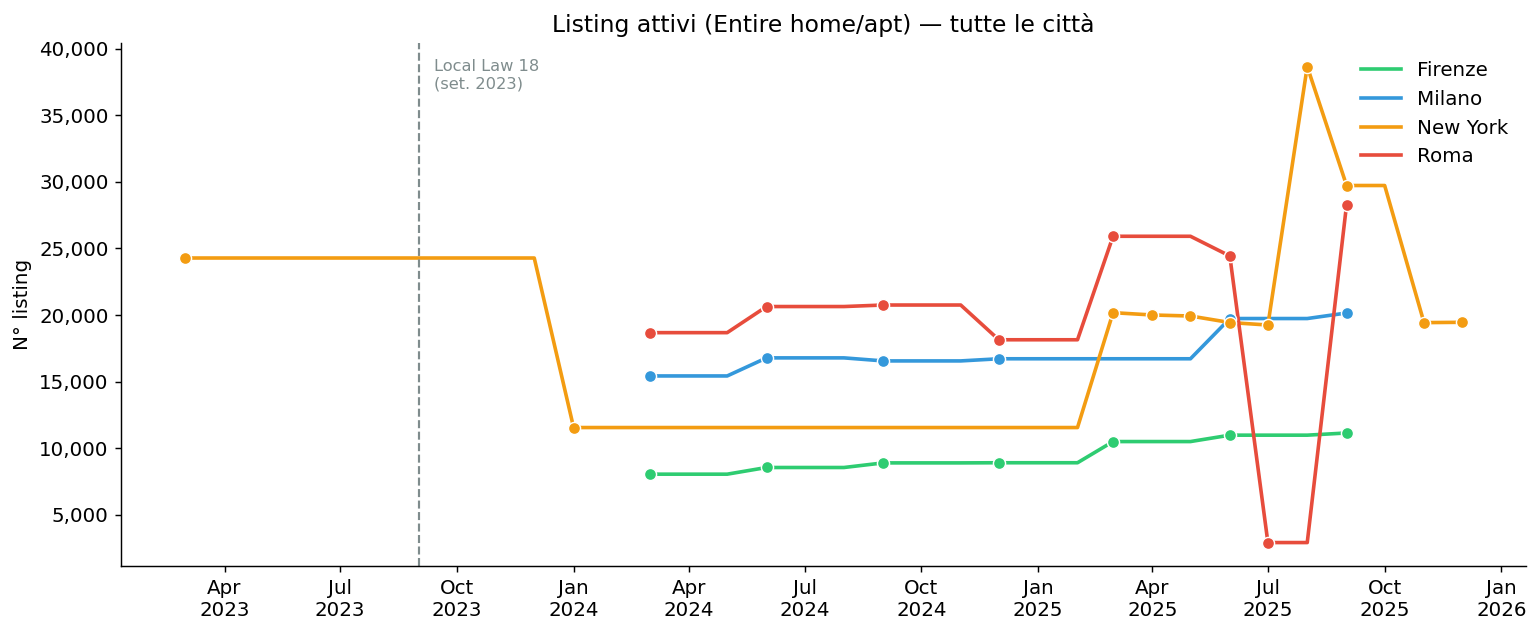

Salvato → plots/01_listing_trends.png


In [14]:
# ── 3.1: Trend listing mensili per città ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

for city, s in ts_airbnb_monthly.items():
    ax.plot(s.index, s.values, color=COLORS[city], linewidth=2, label=city)
    # Marcatori sugli snapshot reali
    snap_dates = ts_airbnb_raw[ts_airbnb_raw['city'] == city]['date']
    snap_vals  = s.reindex(snap_dates).dropna()
    ax.scatter(snap_vals.index, snap_vals.values, color=COLORS[city],
               s=45, zorder=5, edgecolors='white', linewidths=0.8)

# Annotazione Local Law 18
ll18 = pd.Timestamp('2023-09-01')
ax.axvline(ll18, color='#7f8c8d', linestyle='--', linewidth=1.2)
ylim = ax.get_ylim()
ax.text(ll18 + pd.DateOffset(days=12), ylim[1] * 0.97,
        'Local Law 18\n(set. 2023)', fontsize=9, color='#7f8c8d', va='top')

ax.set_title('Listing attivi (Entire home/apt) — tutte le città')
ax.set_ylabel('N° listing')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.legend(frameon=False)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
fig.savefig(f'{PLOT_DIR}/01_listing_trends.png', bbox_inches='tight')
plt.show()
print('Salvato → plots/01_listing_trends.png')


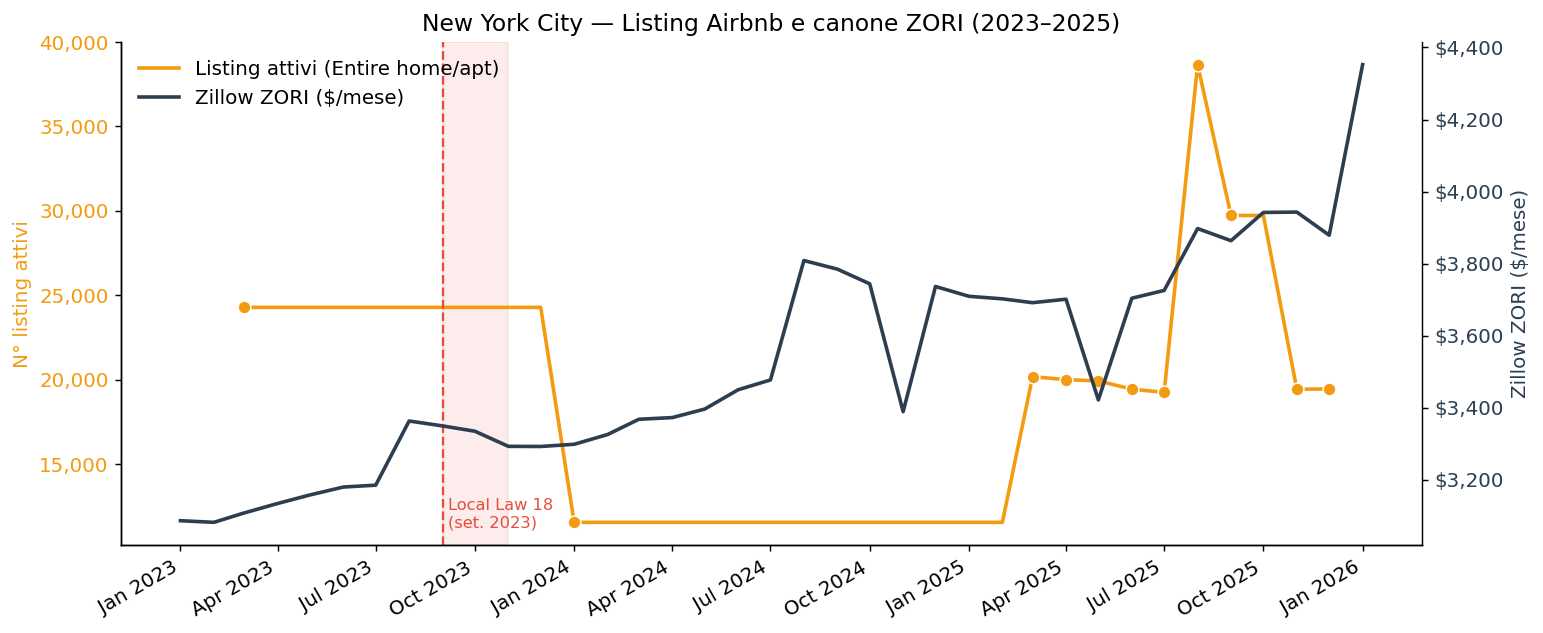

Salvato → plots/02_ny_ll18_zori.png


In [15]:
# ── 3.2: NYC — Local Law 18: listing + ZORI dual axis ────────────────────────
ny_listings = ts_airbnb_monthly['New York']
ny_snaps = ts_airbnb_raw[ts_airbnb_raw['city'] == 'New York']['date']

fig, ax1 = plt.subplots(figsize=(12, 5))

col_ny = COLORS['New York']
ax1.plot(ny_listings.index, ny_listings.values,
         color=col_ny, linewidth=2, label='Listing attivi (Entire home/apt)')
snap_vals_ny = ny_listings.reindex(ny_snaps).dropna()
ax1.scatter(snap_vals_ny.index, snap_vals_ny.values,
            color=col_ny, s=50, zorder=5, edgecolors='white', linewidths=0.8)
ax1.set_ylabel('N° listing attivi', color=col_ny)
ax1.tick_params(axis='y', labelcolor=col_ny)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

ax2 = ax1.twinx()
ax2.plot(ts_zori_ny.index, ts_zori_ny.values,
         color='#2c3e50', linewidth=2, label='Zillow ZORI ($/mese)')
ax2.set_ylabel('Zillow ZORI ($/mese)', color='#2c3e50')
ax2.tick_params(axis='y', labelcolor='#2c3e50')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x):,}'))
ax2.spines['right'].set_visible(True)

ll18 = pd.Timestamp('2023-09-01')
ax1.axvspan(ll18, ll18 + pd.DateOffset(months=2), alpha=0.10, color='#e74c3c')
ax1.axvline(ll18, color='#e74c3c', linestyle='--', linewidth=1.3)
ylim1 = ax1.get_ylim()
ax1.text(ll18 + pd.DateOffset(days=5), ylim1[0] + (ylim1[1] - ylim1[0]) * 0.03,
         'Local Law 18\n(set. 2023)', fontsize=9, color='#e74c3c', va='bottom')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, frameon=False, loc='upper left')

ax1.set_title('New York City — Listing Airbnb e canone ZORI (2023–2025)')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha='right')
plt.tight_layout()
fig.savefig(f'{PLOT_DIR}/02_ny_ll18_zori.png', bbox_inches='tight')
plt.show()
print('Salvato → plots/02_ny_ll18_zori.png')


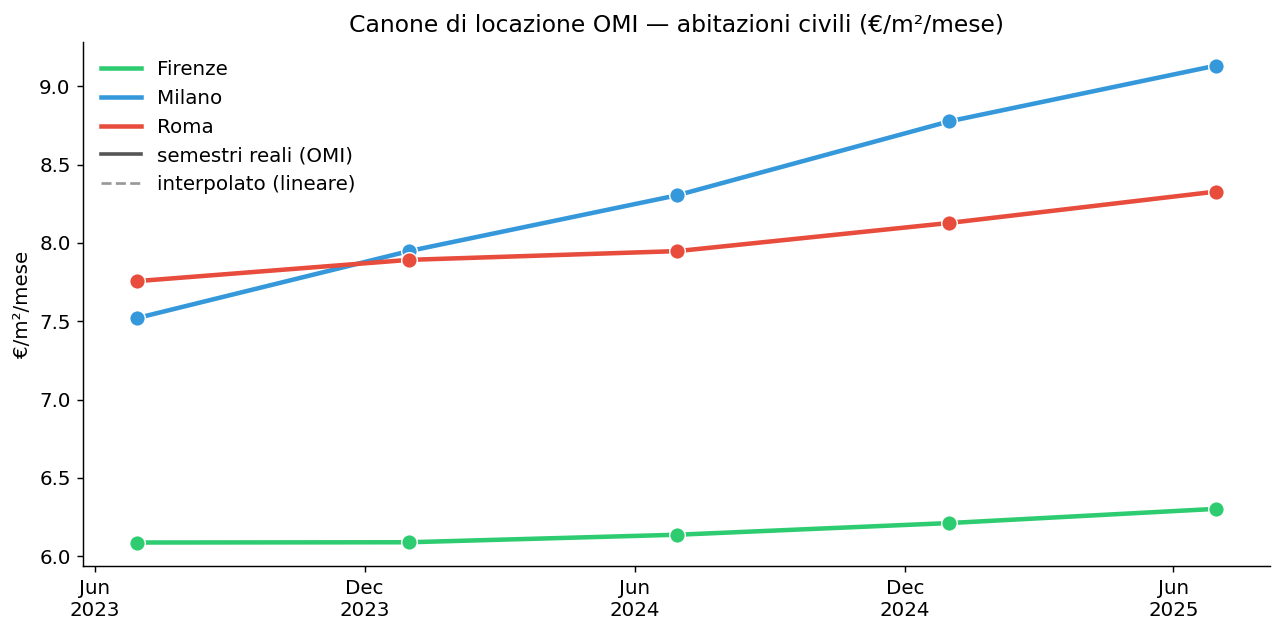

Salvato → plots/03_omi_trends.png


In [16]:
# ── 3.3: OMI canone locazione Italia — semestri reali + interpolato ───────────
import matplotlib.lines as mlines

fig, ax = plt.subplots(figsize=(10, 5))

for city, s_monthly in ts_omi_monthly.items():
    c = COLORS[city]
    ax.plot(s_monthly.index, s_monthly.values, color=c, linewidth=1.5,
            linestyle='--', alpha=0.5)
    sem_df = omi_city_sem[omi_city_sem['city'] == city].sort_values('date')
    ax.plot(sem_df['date'], sem_df['loc_medio'], color=c, linewidth=2.5, label=city)
    ax.scatter(sem_df['date'], sem_df['loc_medio'], color=c, s=75, zorder=5,
               edgecolors='white', linewidths=0.8)

ax.set_title('Canone di locazione OMI — abitazioni civili (€/m²/mese)')
ax.set_ylabel('€/m²/mese')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[6, 12]))

# Legenda: città + note sulle linee
city_handles, city_labels = ax.get_legend_handles_labels()
h_solid = mlines.Line2D([], [], color='#555', linewidth=2, label='semestri reali (OMI)')
h_dash  = mlines.Line2D([], [], color='#555', linewidth=1.5, linestyle='--',
                        alpha=0.6, label='interpolato (lineare)')
ax.legend(city_handles + [h_solid, h_dash],
          city_labels + ['semestri reali (OMI)', 'interpolato (lineare)'],
          frameon=False)
plt.tight_layout()
fig.savefig(f'{PLOT_DIR}/03_omi_trends.png', bbox_inches='tight')
plt.show()
print('Salvato → plots/03_omi_trends.png')


C:\Users\user\AppData\Local\Temp\ipykernel_20188\990085087.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp_it = ax_it.boxplot(
C:\Users\user\AppData\Local\Temp\ipykernel_20188\990085087.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp_ny = ax_ny.boxplot(


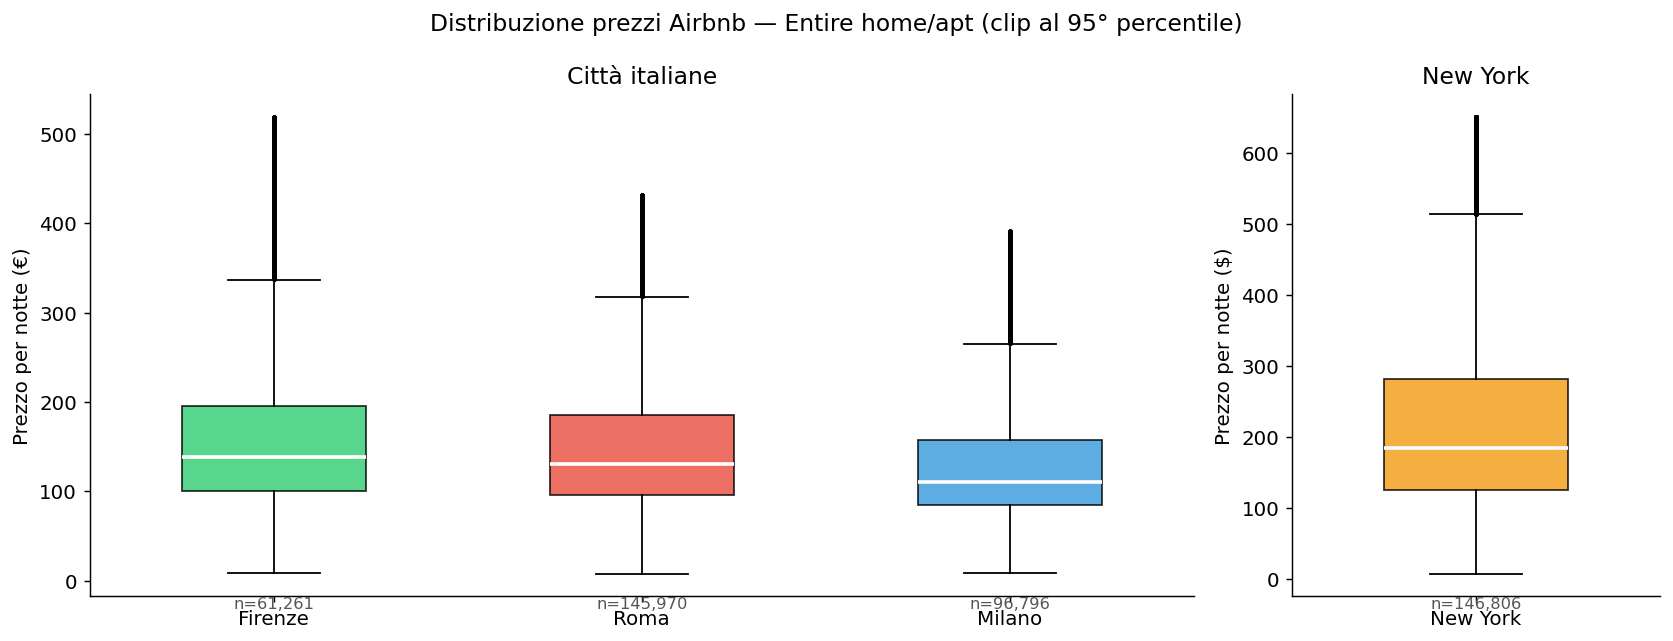

Salvato → plots/04_price_distribution.png


In [17]:
# ── 3.4: Distribuzione prezzi Airbnb per città (boxplot, clip 95° percentile) ─
# ⚠️ EUR (città italiane) e USD (New York) non sono comparabili → subplot separati.
cities_it = ['Firenze', 'Roma', 'Milano']

fig, (ax_it, ax_ny) = plt.subplots(1, 2, figsize=(13, 5),
                                    gridspec_kw={'width_ratios': [3, 1]})

# --- Italia (EUR) ---
data_it = []
for city in cities_it:
    prices = df_master[df_master['city'] == city]['price'].dropna()
    cap = prices.quantile(0.95)
    data_it.append(prices[prices <= cap].values)

bp_it = ax_it.boxplot(
    data_it, labels=cities_it, patch_artist=True,
    medianprops={'color': 'white', 'linewidth': 2},
    flierprops={'marker': '.', 'markersize': 3, 'alpha': 0.25},
    widths=0.5,
)
for patch, city in zip(bp_it['boxes'], cities_it):
    patch.set_facecolor(COLORS[city])
    patch.set_alpha(0.8)

ax_it.set_title('Città italiane')
ax_it.set_ylabel('Prezzo per notte (€)')
for i, (city, data) in enumerate(zip(cities_it, data_it), 1):
    ax_it.text(i, ax_it.get_ylim()[0], f'n={len(data):,}',
               ha='center', va='top', fontsize=9, color='#555', clip_on=False)

# --- New York (USD) ---
prices_ny = df_master[df_master['city'] == 'New York']['price'].dropna()
cap_ny = prices_ny.quantile(0.95)
data_ny = [prices_ny[prices_ny <= cap_ny].values]

bp_ny = ax_ny.boxplot(
    data_ny, labels=['New York'], patch_artist=True,
    medianprops={'color': 'white', 'linewidth': 2},
    flierprops={'marker': '.', 'markersize': 3, 'alpha': 0.25},
    widths=0.5,
)
bp_ny['boxes'][0].set_facecolor(COLORS['New York'])
bp_ny['boxes'][0].set_alpha(0.8)
ax_ny.set_title('New York')
ax_ny.set_ylabel('Prezzo per notte ($)')
ax_ny.text(1, ax_ny.get_ylim()[0], f'n={len(data_ny[0]):,}',
           ha='center', va='top', fontsize=9, color='#555', clip_on=False)

fig.suptitle('Distribuzione prezzi Airbnb — Entire home/apt (clip al 95° percentile)',
             fontsize=13)
plt.tight_layout()
fig.savefig(f'{PLOT_DIR}/04_price_distribution.png', bbox_inches='tight')
plt.show()
print('Salvato → plots/04_price_distribution.png')


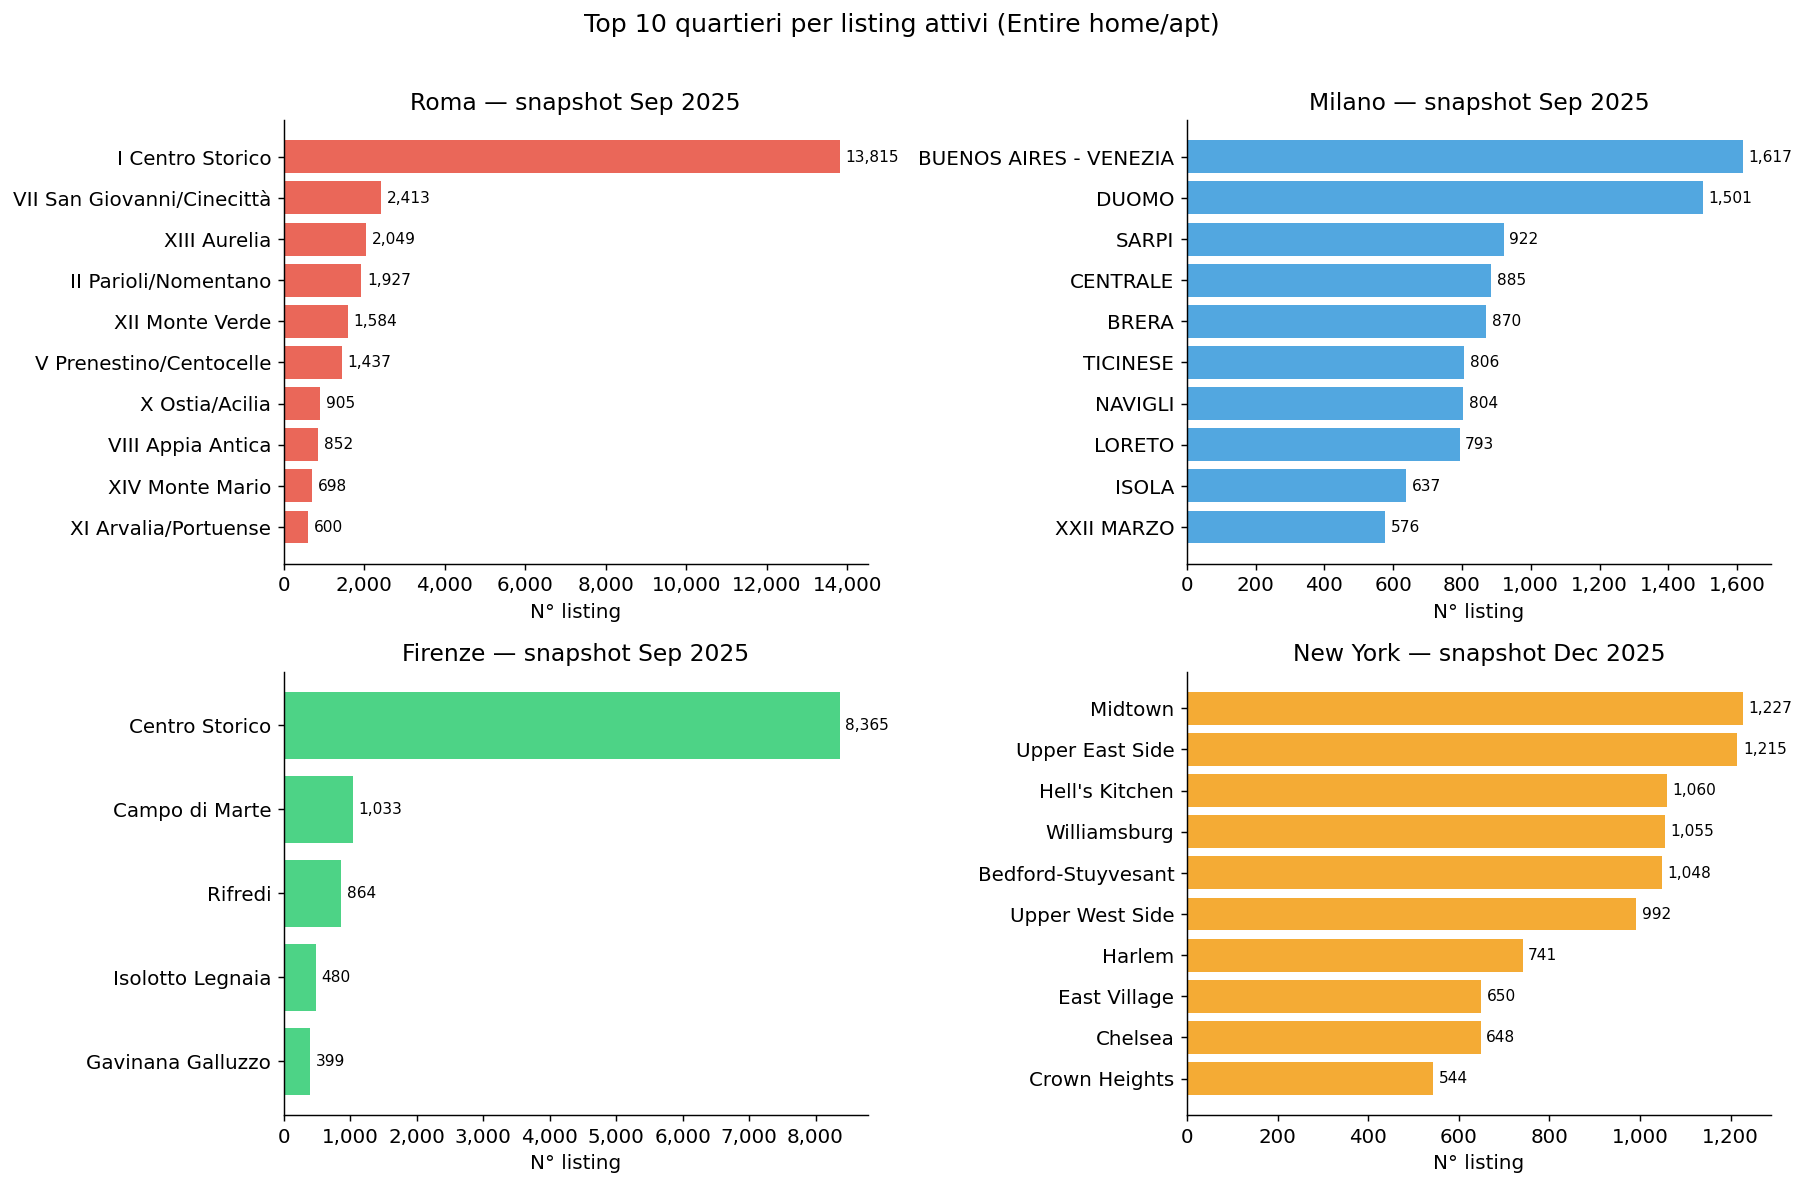

Salvato → plots/05_top_neighbourhoods.png


In [18]:
# -- 3.5: Top 10 quartieri per n listing -- snapshot piu recente ---------------
# Filtro per mese (non per data esatta): last_scraped varia listing per listing
# nei file InsideAirbnb, quindi date.max() darebbe un sottoinsieme minuscolo.
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, city in zip(axes, ['Roma', 'Milano', 'Firenze', 'New York']):
    sub = df_master[df_master['city'] == city].copy()
    sub['month'] = sub['date'].dt.to_period('M')
    latest_month = sub['month'].max()
    sub_latest = sub[sub['month'] == latest_month]
    top10 = (
        sub_latest.groupby('neighbourhood').size()
        .nlargest(10)
        .sort_values()
    )
    ax.barh(top10.index, top10.values, color=COLORS[city], alpha=0.85)
    ax.set_title(f'{city} — snapshot {latest_month.strftime("%b %Y")}')
    ax.set_xlabel('N° listing')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    vmax = top10.values.max()
    for y_pos, val in zip(range(len(top10)), top10.values):
        ax.text(val + vmax * 0.01, y_pos, f'{int(val):,}',
                va='center', fontsize=8.5)

plt.suptitle('Top 10 quartieri per listing attivi (Entire home/apt)',
             fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig(f'{PLOT_DIR}/05_top_neighbourhoods.png', bbox_inches='tight')
plt.show()
print('Salvato → plots/05_top_neighbourhoods.png')
